# Phase 3: Cluster Profiling & GWU Peer Analysis

**Input:** Feature matrix + clustering assignments from Phases 1 & 2

**Analyses:** Cluster profiles → GWU peer identification → Radar charts → Salary disparity → Placement gaps → Enrollment composition → Admission metrics

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Load both artifact files
with open('feature_engineering_artifacts.pkl', 'rb') as f:
    fe = pickle.load(f)
with open('clustering_artifacts.pkl', 'rb') as f:
    cl = pickle.load(f)

df_unscaled = fe['df_unscaled']
df_scaled = fe['df_scaled']
labels = fe['labels']
target = fe['target']
gwu_name = fe['gwu_name']
gwu_idx = fe['gwu_idx']
feature_groups = fe['feature_groups']

kmeans_labels = cl['kmeans_labels']
cluster_names = cl['cluster_names']
OPTIMAL_K = cl['OPTIMAL_K']
gwu_cluster_id = cl['gwu_cluster_id']
aspiration_cluster_id = cl['aspiration_cluster_id']

ranks = labels['rank'].values
school_names = df_unscaled.index.tolist()

print(f"Loaded: {len(school_names)} schools, {df_unscaled.shape[1]} features, k={OPTIMAL_K} clusters")
print(f"GWU cluster:        {gwu_cluster_id} — {cluster_names[gwu_cluster_id]}")
print(f"Aspiration cluster:  {aspiration_cluster_id} — {cluster_names[aspiration_cluster_id]}")

Loaded: 121 schools, 40 features, k=6 clusters
GWU cluster:        2 — Mid-Upper (46-120)
Aspiration cluster:  1 — Strong (13-118)


## Step 3.1 — Cluster Profile Summary Table

In [2]:
# Build cluster profile: mean of each feature per cluster
df_profile = df_unscaled.copy()
df_profile['cluster_id'] = kmeans_labels
df_profile['rank'] = ranks

# Summary statistics per cluster
profile_stats = []
for c in range(OPTIMAL_K):
    mask = df_profile['cluster_id'] == c
    c_data = df_profile[mask]
    stats = {
        'Cluster': f"C{c}: {cluster_names[c]}",
        'Count': mask.sum(),
        'Rank Range': f"{int(c_data['rank'].min())}-{int(c_data['rank'].max())}",
        'Mean Rank': c_data['rank'].mean(),
    }
    for col in df_unscaled.columns:
        stats[col] = c_data[col].mean()
    profile_stats.append(stats)

profile_df = pd.DataFrame(profile_stats)
profile_df = profile_df.set_index('Cluster')

# Select key features that actually exist in the data
important_features = [
    'ranking_scores_two_year_averages.peer_assessment_score_out_of_5',
    'ranking_scores_two_year_averages.recruiter_assessment_score_out_of_5',
    'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg',
    'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg',
    'ranking_scores_two_year_averages.avg_starting_salary_and_bonus_two_yr_avg',
    'ranking_scores_two_year_averages.acceptance_rate',
    'student_body_fulltime_mba.international_students_percent',
    'student_body_fulltime_mba.enrollment',
    'student_body_fulltime_mba.female_percent',
]
# Only keep features that exist in df_unscaled (some may have been dropped during dedup)
existing_features = [f for f in important_features if f in df_unscaled.columns]

key_cols = ['Count', 'Rank Range', 'Mean Rank'] + existing_features
display_df = profile_df[key_cols].T

# Use short names for display
short_idx = []
for c in display_df.index:
    if c in ['Count', 'Rank Range', 'Mean Rank']:
        short_idx.append(c)
    else:
        short_idx.append(c.split('.')[-1][:40])
display_df.index = short_idx

print("Cluster Profile Summary (key features):\n")
print(display_df.to_string())

Cluster Profile Summary (key features):

Cluster                                  C0: Elite (1-43) C1: Strong (13-118) C2: Mid-Upper (46-120) C3: Mid-Lower (24-113) C4: Lower (77-96) C5: Bottom (68-120)
Count                                                  26                  37                     21                     26                 2                   9
Rank Range                                           1-43              13-118                 46-120                 24-113             77-96              68-120
Mean Rank                                       15.115385           49.621622              83.428571                   86.5              86.5           98.888889
recruiter_assessment_score_out_of_5              4.073077            3.415301               3.161905               3.084072              2.85            3.544444
fulltime_employed_at_graduation_two_yr_a            0.731            0.674503                0.54419               0.628423            0.8635        

## Step 3.2 — GWU's Cluster Peers and Aspiration Cluster

In [3]:
# GWU's peers
gwu_peer_mask = kmeans_labels == gwu_cluster_id
gwu_peers = pd.DataFrame({
    'school_name': np.array(school_names)[gwu_peer_mask],
    'rank': ranks[gwu_peer_mask]
}).sort_values('rank')

print(f"GWU's Peer Cluster ({cluster_names[gwu_cluster_id]}) — {len(gwu_peers)} schools:")
print("=" * 60)
for _, row in gwu_peers.iterrows():
    marker = " ◄◄◄ GWU" if row['school_name'] == gwu_name else ""
    print(f"  Rank {int(row['rank']):3d}  {row['school_name'][:50]}{marker}")

# Aspiration cluster
asp_mask = kmeans_labels == aspiration_cluster_id
asp_peers = pd.DataFrame({
    'school_name': np.array(school_names)[asp_mask],
    'rank': ranks[asp_mask]
}).sort_values('rank')

print(f"\nAspiration Cluster ({cluster_names[aspiration_cluster_id]}) — {len(asp_peers)} schools:")
print("=" * 60)
for _, row in asp_peers.iterrows():
    print(f"  Rank {int(row['rank']):3d}  {row['school_name'][:50]}")

# Distance analysis
from scipy.spatial.distance import euclidean
gwu_scaled = df_scaled.values[gwu_idx]
own_centroid = cl['kmeans_centroids'][gwu_cluster_id]
asp_centroid = cl['kmeans_centroids'][aspiration_cluster_id]

dist_own = euclidean(gwu_scaled, own_centroid)
dist_asp = euclidean(gwu_scaled, asp_centroid)

print(f"\nGWU distance to own cluster centroid:        {dist_own:.2f}")
print(f"GWU distance to aspiration cluster centroid:  {dist_asp:.2f}")
print(f"Ratio (own/aspiration):                       {dist_own/dist_asp:.2f}")

GWU's Peer Cluster (Mid-Upper (46-120)) — 21 schools:
  Rank  46  Boston University
  Rank  54  Syracuse University
  Rank  58  Fordham University
  Rank  58  American University
  Rank  61  George Washington University ◄◄◄ GWU
  Rank  65  University of California--Davis
  Rank  66  Chapman University
  Rank  68  Northeastern University
  Rank  73  Babson College
  Rank  82  Case Western Reserve University
  Rank  86  Lehigh University
  Rank  88  Pepperdine University
  Rank  97  Claremont Graduate University
  Rank  97  University of Denver
  Rank 100  Clarkson University
  Rank 100  Brandeis University
  Rank 100  Rochester Institute of Technology
  Rank 108  University of San Diego
  Rank 110  Drexel University
  Rank 115  Suffolk University
  Rank 120  Pace University

Aspiration Cluster (Strong (13-118)) — 37 schools:
  Rank  13  University of Michigan--Ann Arbor
  Rank  18  Vanderbilt University
  Rank  22  Indiana University
  Rank  24  Ohio State University
  Rank  29  Univers

## Step 3.3 — Radar Chart: GWU vs. Peer Cluster vs. Aspiration Cluster

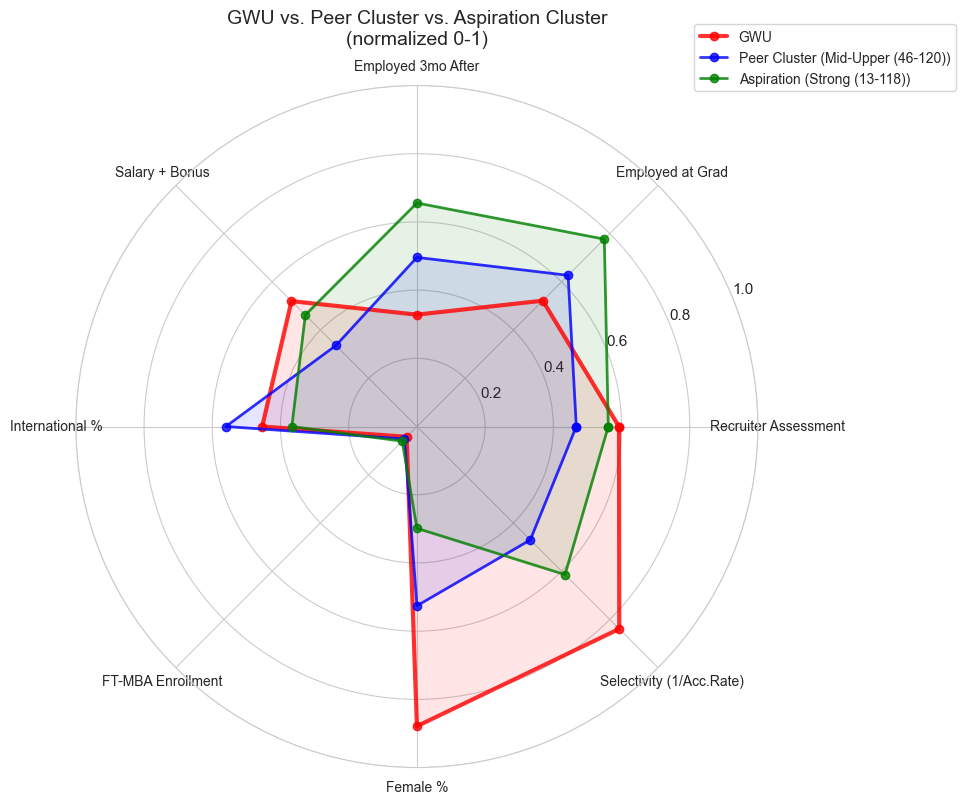


Raw values (before normalization):
Metric                             GWU    Peer Mean   Aspiration  GWU vs Peer
---------------------------------------------------------------------------
  Recruiter Assessment             3.5          3.2          3.4 +        0.3
  Employed at Grad                 0.5          0.5          0.7        -0.1
  Employed 3mo After               0.7          0.8          0.8        -0.1
  Salary + Bonus              133014.0     104638.5     124145.9 +    28375.5
  International %                  0.4          0.4          0.3        -0.1
  FT-MBA Enrollment               90.0        106.7        124.1       -16.7
  Female %                         0.6          0.4          0.3 +        0.2
  Selectivity (1/Acc.Rate)          0.2          0.6          0.4        -0.3


In [4]:
# Select 10 key dimensions for the radar chart
radar_features = {
    'Peer Assessment': 'ranking_scores_two_year_averages.peer_assessment_score_out_of_5',
    'Recruiter Assessment': 'ranking_scores_two_year_averages.recruiter_assessment_score_out_of_5',
    'Employed at Grad': 'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg',
    'Employed 3mo After': 'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg',
    'Salary + Bonus': 'ranking_scores_two_year_averages.avg_starting_salary_and_bonus_two_yr_avg',
    'Avg Base Salary': 'base_salary_overall.average_base_salary',
    'International %': 'student_body_fulltime_mba.international_students_percent',
    'FT-MBA Enrollment': 'student_body_fulltime_mba.enrollment',
    'Female %': 'student_body_fulltime_mba.female_percent',
}

# Filter to features that exist in df_unscaled
radar_features = {k: v for k, v in radar_features.items() if v in df_unscaled.columns}

# Also add acceptance rate (invert so higher = more selective = better on the chart)
acc_col = 'ranking_scores_two_year_averages.acceptance_rate'
if acc_col in df_unscaled.columns:
    radar_features['Selectivity (1/Acc.Rate)'] = acc_col

# Get values for GWU, peer mean, aspiration mean
gwu_vals = {}
peer_vals = {}
asp_vals = {}

for label, col in radar_features.items():
    gwu_v = df_unscaled.loc[gwu_name, col]
    peer_v = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean()
    asp_v = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    
    # For selectivity, invert so lower acceptance rate = higher value
    if 'Selectivity' in label:
        gwu_v = 100 - gwu_v
        peer_v = 100 - peer_v
        asp_v = 100 - asp_v
    
    gwu_vals[label] = gwu_v
    peer_vals[label] = peer_v
    asp_vals[label] = asp_v

# Normalize to 0-1 using min-max across the full dataset
for label, col in radar_features.items():
    all_vals = df_unscaled[col].values
    if 'Selectivity' in label:
        all_vals = 100 - all_vals
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    rng = vmax - vmin if vmax - vmin > 0 else 1
    gwu_vals[label] = (gwu_vals[label] - vmin) / rng
    peer_vals[label] = (peer_vals[label] - vmin) / rng
    asp_vals[label] = (asp_vals[label] - vmin) / rng

# Plot radar chart
categories = list(radar_features.keys())
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for vals, color, label, lw in [
    (gwu_vals, 'red', 'GWU', 3),
    (peer_vals, 'blue', f'Peer Cluster ({cluster_names[gwu_cluster_id]})', 2),
    (asp_vals, 'green', f'Aspiration ({cluster_names[aspiration_cluster_id]})', 2),
]:
    values = [vals[c] for c in categories] + [vals[categories[0]]]
    ax.plot(angles, values, 'o-', linewidth=lw, label=label, color=color, alpha=0.8)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('GWU vs. Peer Cluster vs. Aspiration Cluster\n(normalized 0-1)', fontsize=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

# Print the raw values for reference
print("\nRaw values (before normalization):")
print(f"{'Metric':<25s} {'GWU':>12s} {'Peer Mean':>12s} {'Aspiration':>12s} {'GWU vs Peer':>12s}")
print("-" * 75)
for label, col in radar_features.items():
    gv = df_unscaled.loc[gwu_name, col]
    pv = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean()
    av = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    diff = gv - pv
    direction = "+" if diff > 0 else ""
    print(f"  {label:<23s} {gv:>12.1f} {pv:>12.1f} {av:>12.1f} {direction}{diff:>11.1f}")

## Step 3.4 — Salary Disparity Analysis (CSV data)

Salary Comparison: GWU vs. Clusters

                                  Metric      GWU  Peer Cluster Mean  Aspiration Mean  GWU vs Peer  GWU vs Aspiration
avg_starting_salary_and_bonus_two_yr_avg 133014.0      104638.523810    124145.872479 28375.476190        8868.127521
                         low_base_salary  75000.0       55108.095238     61177.917058 19891.904762       13822.082942
                        high_base_salary 200000.0      188977.142857    175011.633892 11022.857143       24988.366108
                     average_base_salary 113333.0       81577.241326    108955.196631 31755.758674        4377.803369
                   average_signing_bonus  16875.0       13756.911263     23674.545657  3118.088737       -6799.545657
                salary_gap_us_vs_foreign   8617.0       18538.331206      -141.746412 -9921.331206        8758.746412


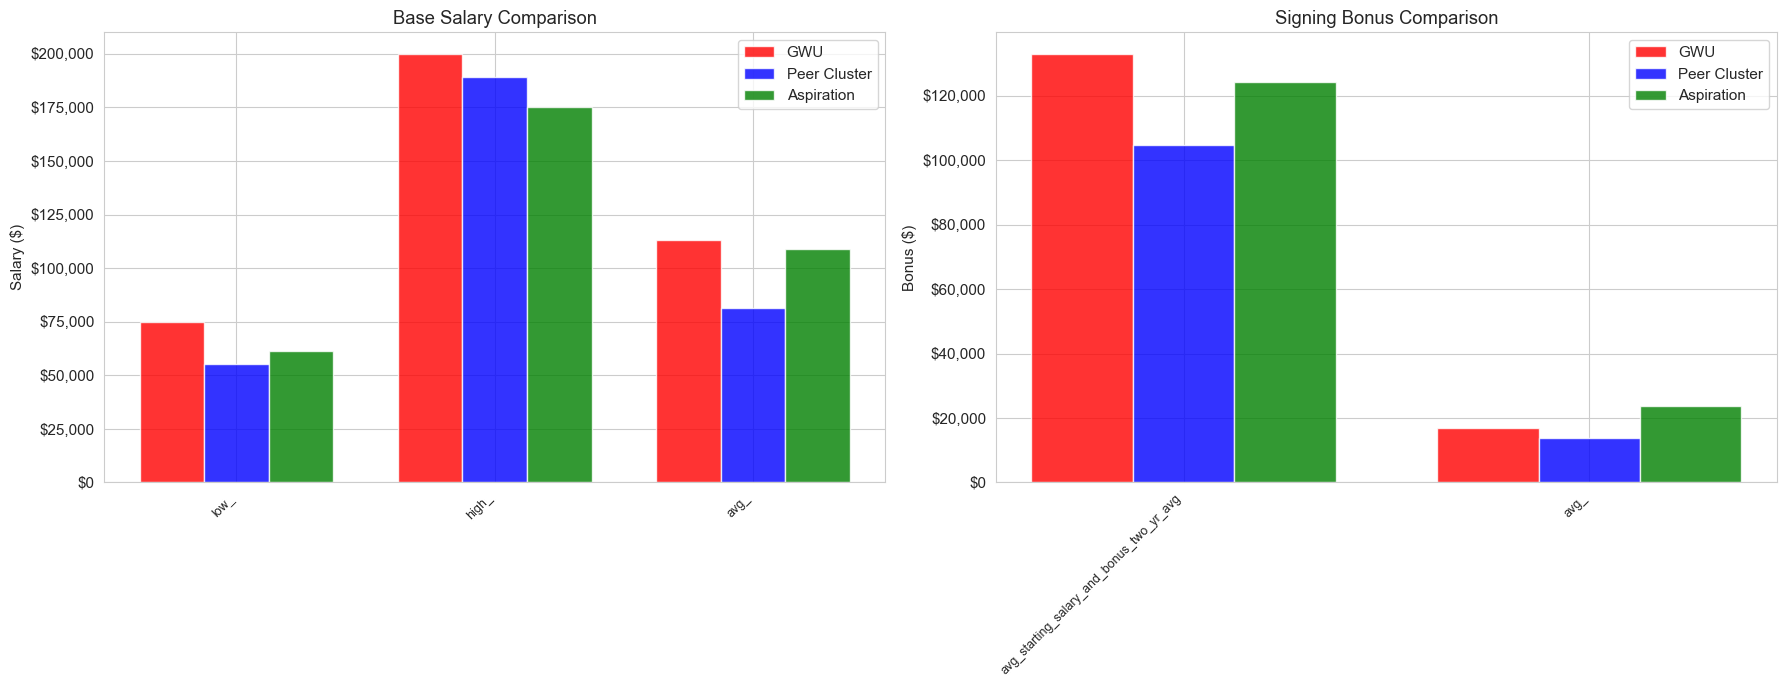


US vs Foreign National Salary Gap (within peer cluster):
  American University                        gap: $   +20,600
  Babson College                             gap: $    +9,472
  Boston University                          gap: $    +6,988
  Brandeis University                        gap: $   -19,437
  Case Western Reserve University            gap: $   +40,599
  Chapman University                         gap: $    +5,906
  Claremont Graduate University              gap: $   -25,056
  Clarkson University                        gap: $   +92,000
  Drexel University                          gap: $   +68,333
  Fordham University                         gap: $   +33,526
  George Washington University               gap: $    +8,617 ◄ GWU
  Lehigh University                          gap: $    -1,578
  Northeastern University                    gap: $      -816
  Pace University                            gap: $    +2,286
  Pepperdine University                      gap: $      -676
  Roch

In [5]:
# Salary features comparison: GWU vs Peer cluster mean vs Aspiration cluster mean
salary_cols = [c for c in df_unscaled.columns if 'salary' in c.lower() or 'bonus' in c.lower() or 'reporting' in c.lower()]
salary_cols = [c for c in salary_cols if c in df_unscaled.columns]

salary_data = []
for col in salary_cols:
    short = col.split('.')[-1]
    gwu_v = df_unscaled.loc[gwu_name, col]
    peer_v = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean()
    asp_v = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    salary_data.append({
        'Metric': short,
        'GWU': gwu_v,
        'Peer Cluster Mean': peer_v,
        'Aspiration Mean': asp_v,
        'GWU vs Peer': gwu_v - peer_v,
        'GWU vs Aspiration': gwu_v - asp_v,
    })

salary_df = pd.DataFrame(salary_data)
print("Salary Comparison: GWU vs. Clusters\n")
print(salary_df.to_string(index=False))

# Grouped bar chart for salary metrics
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Base salary comparison
base_metrics = [s for s in salary_data if 'base_salary' in s['Metric'] and 'total' not in s['Metric']]
if base_metrics:
    x = range(len(base_metrics))
    width = 0.25
    labels_plot = [m['Metric'].replace('average_', 'avg_').replace('base_salary', '') for m in base_metrics]
    
    axes[0].bar([i - width for i in x], [m['GWU'] for m in base_metrics], width, label='GWU', color='red', alpha=0.8)
    axes[0].bar(x, [m['Peer Cluster Mean'] for m in base_metrics], width, label='Peer Cluster', color='blue', alpha=0.8)
    axes[0].bar([i + width for i in x], [m['Aspiration Mean'] for m in base_metrics], width, label='Aspiration', color='green', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_plot, rotation=45, ha='right', fontsize=9)
    axes[0].set_ylabel('Salary ($)')
    axes[0].set_title('Base Salary Comparison')
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Signing bonus comparison
bonus_metrics = [s for s in salary_data if 'bonus' in s['Metric'] and 'total' not in s['Metric']]
if bonus_metrics:
    x = range(len(bonus_metrics))
    labels_plot = [m['Metric'].replace('average_', 'avg_').replace('signing_bonus', '') for m in bonus_metrics]
    
    axes[1].bar([i - width for i in x], [m['GWU'] for m in bonus_metrics], width, label='GWU', color='red', alpha=0.8)
    axes[1].bar(x, [m['Peer Cluster Mean'] for m in bonus_metrics], width, label='Peer Cluster', color='blue', alpha=0.8)
    axes[1].bar([i + width for i in x], [m['Aspiration Mean'] for m in bonus_metrics], width, label='Aspiration', color='green', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels_plot, rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel('Bonus ($)')
    axes[1].set_title('Signing Bonus Comparison')
    axes[1].legend()
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# US vs Foreign salary gap within peer cluster
gap_col = 'derived.salary_gap_us_vs_foreign'
if gap_col in df_unscaled.columns:
    print(f"\nUS vs Foreign National Salary Gap (within peer cluster):")
    peer_schools = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]]
    for name in peer_schools.index:
        gap = peer_schools.loc[name, gap_col]
        marker = " ◄ GWU" if name == gwu_name else ""
        print(f"  {name[:40]:<42s} gap: ${gap:>+10,.0f}{marker}")

## Step 3.5 — Placement Metrics Gap Analysis

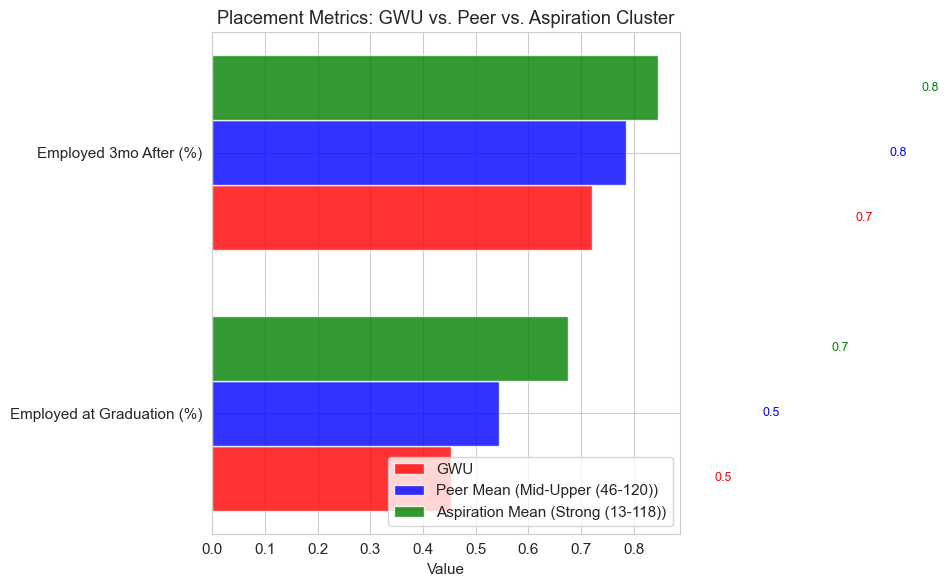


Placement rate within GWU's peer cluster:
School                                         At Grad  3mo After
-----------------------------------------------------------------
  Clarkson University                             0.8%       1.0%
  Syracuse University                             0.7%       0.8%
  Chapman University                              0.7%       0.9%
  University of Denver                            0.6%       0.8%
  Claremont Graduate University                   0.6%       0.8%
  Fordham University                              0.6%       0.9%
  American University                             0.6%       0.9%
  Suffolk University                              0.5%       0.8%
  Brandeis University                             0.5%       0.8%
  Pepperdine University                           0.5%       0.7%
  University of San Diego                         0.5%       0.6%
  Lehigh University                               0.5%       0.9%
  Babson College                 

In [6]:
# Placement metrics
placement_cols = {
    'Employed at Graduation (%)': 'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg',
    'Employed 3mo After (%)': 'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg',
    'FT Graduates (count)': 'career_and_salary_single_year.full_time_graduates',
    'Seeking Employment (count)': 'career_and_salary_single_year.full_time_graduates_seeking_employment',
}
placement_cols = {k: v for k, v in placement_cols.items() if v in df_unscaled.columns}

fig, ax = plt.subplots(figsize=(12, 6))

metrics = list(placement_cols.keys())
gwu_placement = [df_unscaled.loc[gwu_name, col] for col in placement_cols.values()]
peer_placement = [df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean() for col in placement_cols.values()]
asp_placement = [df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean() for col in placement_cols.values()]

y = range(len(metrics))
height = 0.25

ax.barh([i - height for i in y], gwu_placement, height, label='GWU', color='red', alpha=0.8)
ax.barh(y, peer_placement, height, label=f'Peer Mean ({cluster_names[gwu_cluster_id]})', color='blue', alpha=0.8)
ax.barh([i + height for i in y], asp_placement, height, label=f'Aspiration Mean ({cluster_names[aspiration_cluster_id]})', color='green', alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(metrics)
ax.set_xlabel('Value')
ax.set_title('Placement Metrics: GWU vs. Peer vs. Aspiration Cluster')
ax.legend(loc='lower right')

# Add value labels
for i, (gv, pv, av) in enumerate(zip(gwu_placement, peer_placement, asp_placement)):
    ax.text(gv + 0.5, i - height, f'{gv:.1f}', va='center', fontsize=9, color='red')
    ax.text(pv + 0.5, i, f'{pv:.1f}', va='center', fontsize=9, color='blue')
    ax.text(av + 0.5, i + height, f'{av:.1f}', va='center', fontsize=9, color='green')

plt.tight_layout()
plt.show()

# Detailed placement comparison within peer cluster
print("\nPlacement rate within GWU's peer cluster:")
print(f"{'School':<45s} {'At Grad':>8s} {'3mo After':>10s}")
print("-" * 65)
peer_schools = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]]
emp_at_grad_col = 'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg'
emp_3mo_col = 'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg'
if emp_at_grad_col in peer_schools.columns and emp_3mo_col in peer_schools.columns:
    for name in peer_schools.sort_values(emp_at_grad_col, ascending=False).index:
        eg = peer_schools.loc[name, emp_at_grad_col]
        e3 = peer_schools.loc[name, emp_3mo_col]
        marker = " ◄ GWU" if name == gwu_name else ""
        print(f"  {name[:43]:<43s} {eg:>7.1f}% {e3:>9.1f}%{marker}")

## Step 3.6 — Enrollment Composition Analysis

Key questions: Is GWU above or below peers in international vs. domestic proportion? Gender balance? Ethnicity breakdown?

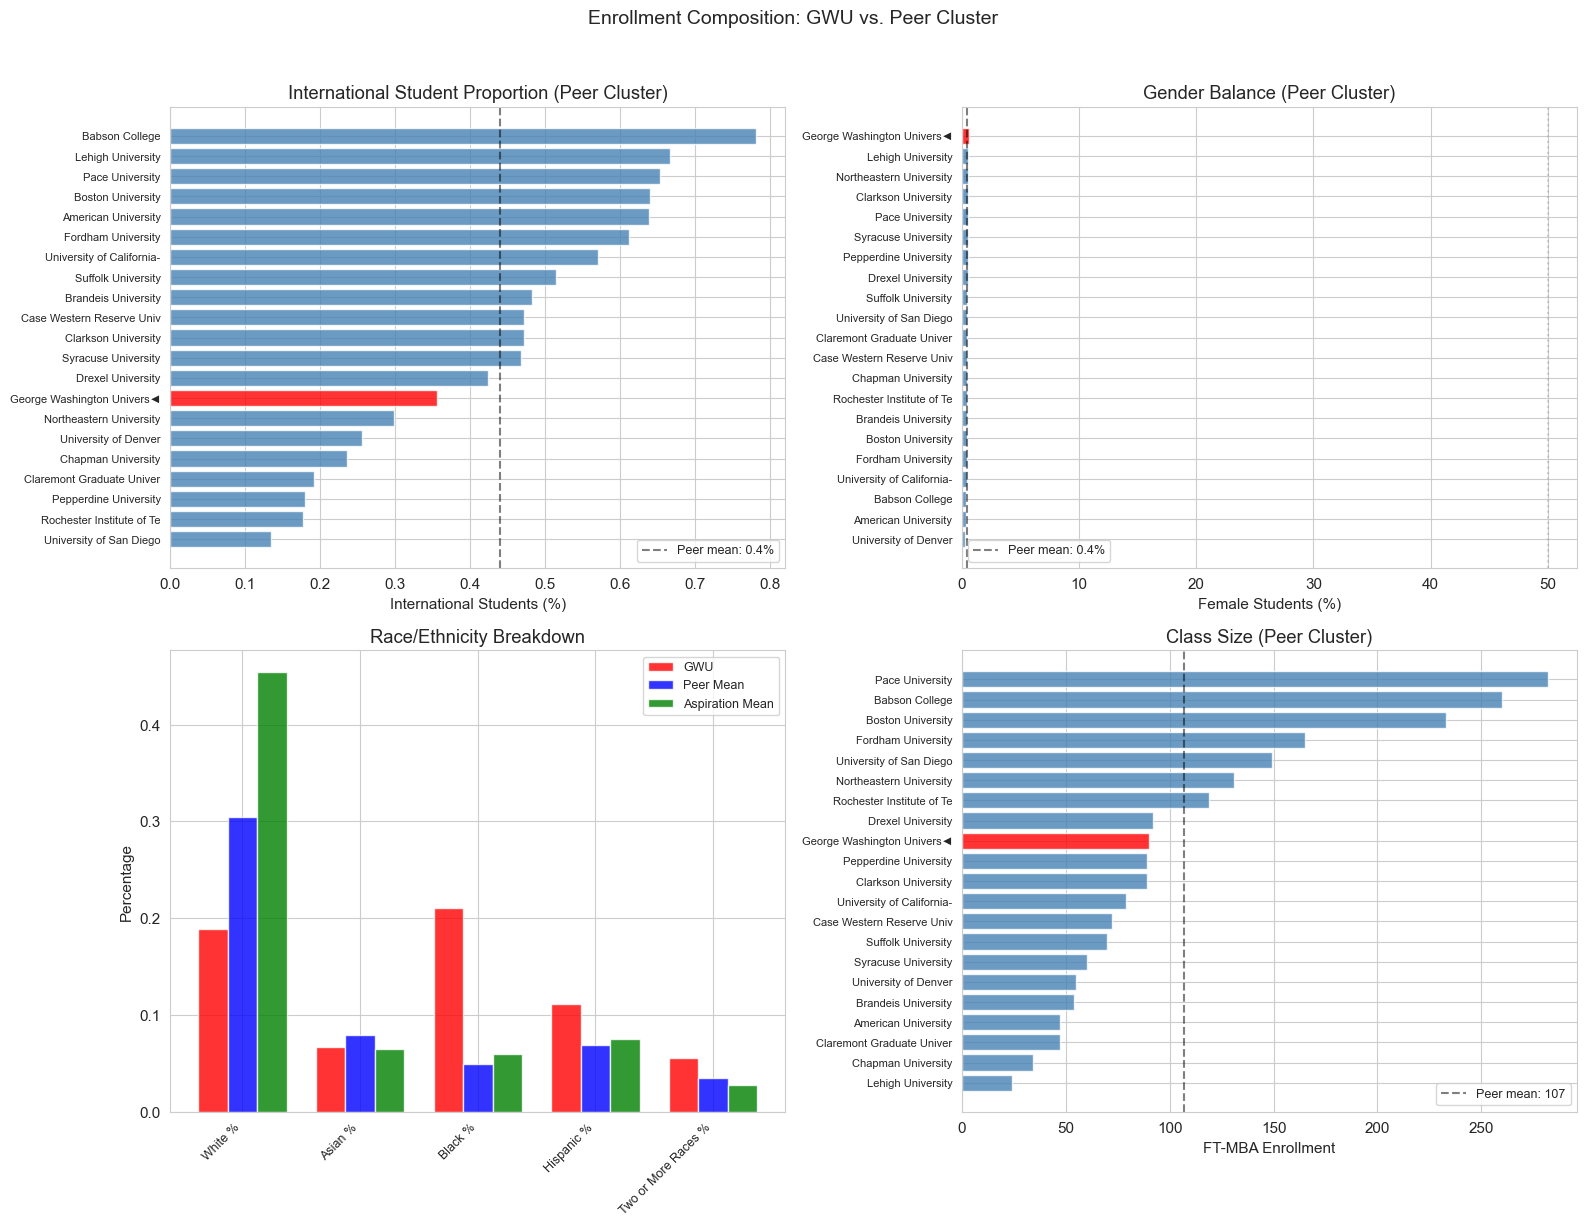


Enrollment Composition Summary:
Metric                           GWU    Peer Mean     Asp Mean    GWU Position
---------------------------------------------------------------------------
  International %                0.4          0.4          0.3    BELOW (-0.1)
  Female %                       0.6          0.4          0.3    ABOVE (+0.2)
  White %                        0.2          0.3          0.5    BELOW (-0.1)
  Asian %                        0.1          0.1          0.1    BELOW (-0.0)
  Black %                        0.2          0.0          0.1    ABOVE (+0.2)
  Hispanic %                     0.1          0.1          0.1    ABOVE (+0.0)
  Two or More Races %            0.1          0.0          0.0    ABOVE (+0.0)
  FT-MBA Enrollment             90.0        106.7        124.1    BELOW (-16.7)


In [7]:
# Enrollment composition features
enrollment_features = {
    'International %': 'student_body_fulltime_mba.international_students_percent',
    'Female %': 'student_body_fulltime_mba.female_percent',
    'White %': 'student_body_fulltime_mba.race_ethnicity.white',
    'Asian %': 'student_body_fulltime_mba.race_ethnicity.asian',
    'Black %': 'student_body_fulltime_mba.race_ethnicity.black',
    'Hispanic %': 'student_body_fulltime_mba.race_ethnicity.hispanic',
    'Two or More Races %': 'student_body_fulltime_mba.race_ethnicity.two_or_more_races',
    'FT-MBA Enrollment': 'student_body_fulltime_mba.enrollment',
}
enrollment_features = {k: v for k, v in enrollment_features.items() if v in df_unscaled.columns}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. International vs Domestic within peer cluster
intl_col = 'student_body_fulltime_mba.international_students_percent'
if intl_col in df_unscaled.columns:
    peer_intl = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][intl_col].sort_values(ascending=False)
    colors = ['red' if n == gwu_name else 'steelblue' for n in peer_intl.index]
    short_names = [n[:25] + ('◄' if n == gwu_name else '') for n in peer_intl.index]
    axes[0, 0].barh(range(len(peer_intl)), peer_intl.values, color=colors, alpha=0.8)
    axes[0, 0].set_yticks(range(len(peer_intl)))
    axes[0, 0].set_yticklabels(short_names, fontsize=8)
    axes[0, 0].axvline(x=peer_intl.mean(), color='black', linestyle='--', alpha=0.5, label=f'Peer mean: {peer_intl.mean():.1f}%')
    axes[0, 0].set_xlabel('International Students (%)')
    axes[0, 0].set_title('International Student Proportion (Peer Cluster)')
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].invert_yaxis()

# 2. Gender balance within peer cluster
female_col = 'student_body_fulltime_mba.female_percent'
if female_col in df_unscaled.columns:
    peer_female = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][female_col].sort_values(ascending=False)
    colors = ['red' if n == gwu_name else 'steelblue' for n in peer_female.index]
    short_names = [n[:25] + ('◄' if n == gwu_name else '') for n in peer_female.index]
    axes[0, 1].barh(range(len(peer_female)), peer_female.values, color=colors, alpha=0.8)
    axes[0, 1].set_yticks(range(len(peer_female)))
    axes[0, 1].set_yticklabels(short_names, fontsize=8)
    axes[0, 1].axvline(x=peer_female.mean(), color='black', linestyle='--', alpha=0.5, label=f'Peer mean: {peer_female.mean():.1f}%')
    axes[0, 1].axvline(x=50, color='grey', linestyle=':', alpha=0.3)
    axes[0, 1].set_xlabel('Female Students (%)')
    axes[0, 1].set_title('Gender Balance (Peer Cluster)')
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].invert_yaxis()

# 3. Race/ethnicity comparison: GWU vs peer mean vs aspiration mean
race_cols = {k: v for k, v in enrollment_features.items() if 'White' in k or 'Asian' in k or 'Black' in k or 'Hispanic' in k or 'Two' in k}
if race_cols:
    race_labels = list(race_cols.keys())
    gwu_race = [df_unscaled.loc[gwu_name, col] for col in race_cols.values()]
    peer_race = [df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean() for col in race_cols.values()]
    asp_race = [df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean() for col in race_cols.values()]
    
    x = np.arange(len(race_labels))
    w = 0.25
    axes[1, 0].bar(x - w, gwu_race, w, label='GWU', color='red', alpha=0.8)
    axes[1, 0].bar(x, peer_race, w, label='Peer Mean', color='blue', alpha=0.8)
    axes[1, 0].bar(x + w, asp_race, w, label='Aspiration Mean', color='green', alpha=0.8)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(race_labels, rotation=45, ha='right', fontsize=9)
    axes[1, 0].set_ylabel('Percentage')
    axes[1, 0].set_title('Race/Ethnicity Breakdown')
    axes[1, 0].legend(fontsize=9)

# 4. Enrollment size comparison
enroll_col = 'student_body_fulltime_mba.enrollment'
if enroll_col in df_unscaled.columns:
    peer_enroll = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][enroll_col].sort_values(ascending=False)
    colors = ['red' if n == gwu_name else 'steelblue' for n in peer_enroll.index]
    short_names = [n[:25] + ('◄' if n == gwu_name else '') for n in peer_enroll.index]
    axes[1, 1].barh(range(len(peer_enroll)), peer_enroll.values, color=colors, alpha=0.8)
    axes[1, 1].set_yticks(range(len(peer_enroll)))
    axes[1, 1].set_yticklabels(short_names, fontsize=8)
    axes[1, 1].axvline(x=peer_enroll.mean(), color='black', linestyle='--', alpha=0.5, label=f'Peer mean: {peer_enroll.mean():.0f}')
    axes[1, 1].set_xlabel('FT-MBA Enrollment')
    axes[1, 1].set_title('Class Size (Peer Cluster)')
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].invert_yaxis()

plt.suptitle('Enrollment Composition: GWU vs. Peer Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary printout
print("\nEnrollment Composition Summary:")
print(f"{'Metric':<25s} {'GWU':>10s} {'Peer Mean':>12s} {'Asp Mean':>12s} {'GWU Position':>15s}")
print("-" * 75)
for label, col in enrollment_features.items():
    gv = df_unscaled.loc[gwu_name, col]
    pv = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean()
    av = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    position = "ABOVE" if gv > pv else "BELOW" if gv < pv else "AT"
    diff = gv - pv
    print(f"  {label:<23s} {gv:>10.1f} {pv:>12.1f} {av:>12.1f} {position:>8s} ({diff:+.1f})")

## Step 3.7 — Admission Metrics Comparison (GMAT, GRE, GPA, Acceptance Rate, Work Experience)

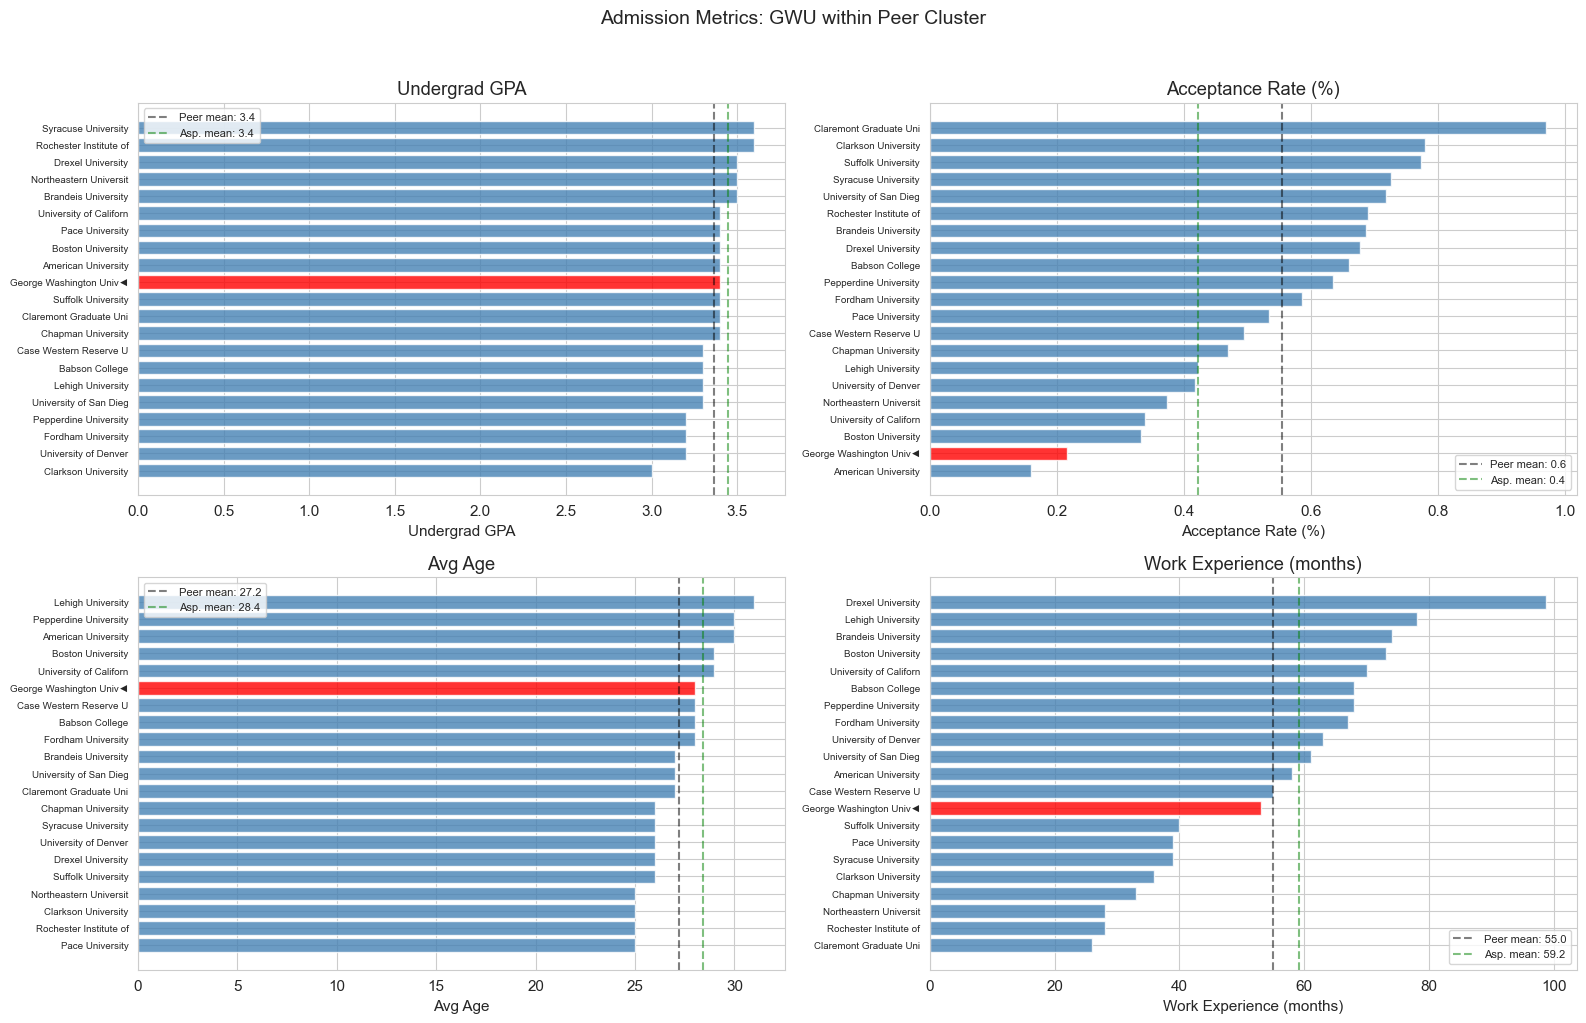


Admission Metrics Comparison:
Metric                           GWU    Peer Mean     Asp Mean    GWU Position
---------------------------------------------------------------------------
  Undergrad GPA                  3.4          3.4          3.4          ABOVE (+0.0)
  Acceptance Rate (%)            0.2          0.6          0.4 MORE SELECTIVE (-0.3)
  Avg Age                       28.0         27.2         28.4          ABOVE (+0.8)
  Work Experience (months)       53.0         55.0         59.2          BELOW (-2.0)
  % Providing GMAT               0.2          0.1          0.2          ABOVE (+0.1)
  % Providing GRE                0.1          0.2          0.2          BELOW (-0.1)

⚠ Note: GWU is test-optional. GMAT scores are based on a small subset of entrants.


In [8]:
admission_features = {
    'GMAT Median (old)': 'ranking_scores_two_year_averages.median_gmat_score_fulltime_old',
    'GMAT Avg (old)': 'gmat_data.average_old_gmat_exam_score',
    'Undergrad GPA': 'ranking_scores_two_year_averages.median_undergraduate_gpa',
    'Acceptance Rate (%)': 'ranking_scores_two_year_averages.acceptance_rate',
    'Avg Age': 'admissions_and_enrollment.average_age_of_new_entrants',
    'Work Experience (months)': 'admissions_and_enrollment.average_work_experience_months',
    '% Providing GMAT': 'gmat_data.percent_new_entrants_providing_gmat_old',
    '% Providing GRE': 'gre_data.percent_new_entrants_providing_gre',
}
admission_features = {k: v for k, v in admission_features.items() if v in df_unscaled.columns}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax_list = axes.flatten()

for i, (label, col) in enumerate(list(admission_features.items())[:4]):
    ax = ax_list[i]
    peer_data = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].sort_values(ascending=False)
    colors = ['red' if n == gwu_name else 'steelblue' for n in peer_data.index]
    short_names = [n[:22] + ('◄' if n == gwu_name else '') for n in peer_data.index]
    
    ax.barh(range(len(peer_data)), peer_data.values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(peer_data)))
    ax.set_yticklabels(short_names, fontsize=7)
    ax.axvline(x=peer_data.mean(), color='black', linestyle='--', alpha=0.5, label=f'Peer mean: {peer_data.mean():.1f}')
    
    # Add aspiration cluster mean
    asp_mean = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    ax.axvline(x=asp_mean, color='green', linestyle='--', alpha=0.5, label=f'Asp. mean: {asp_mean:.1f}')
    
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Admission Metrics: GWU within Peer Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Full admission metrics table
print("\nAdmission Metrics Comparison:")
print(f"{'Metric':<25s} {'GWU':>10s} {'Peer Mean':>12s} {'Asp Mean':>12s} {'GWU Position':>15s}")
print("-" * 75)
for label, col in admission_features.items():
    gv = df_unscaled.loc[gwu_name, col]
    pv = df_unscaled.iloc[gwu_peer_mask.nonzero()[0]][col].mean()
    av = df_unscaled.iloc[asp_mask.nonzero()[0]][col].mean()
    # For acceptance rate, lower is better (more selective)
    if 'Acceptance' in label:
        position = "MORE SELECTIVE" if gv < pv else "LESS SELECTIVE"
    else:
        position = "ABOVE" if gv > pv else "BELOW" if gv < pv else "AT"
    diff = gv - pv
    print(f"  {label:<23s} {gv:>10.1f} {pv:>12.1f} {av:>12.1f} {position:>14s} ({diff:+.1f})")

print("\n⚠ Note: GWU is test-optional. GMAT scores are based on a small subset of entrants.")